In [1]:
# Import required libraries
import pandas as pd
import numpy as np

# NLP libraries
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Download NLTK resources
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\shreyas teja
[nltk_data]     s.m\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to C:\Users\shreyas teja
[nltk_data]     s.m\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [2]:
# Load dataset
df = pd.read_csv("customer_support_tickets.csv")

# Display first 5 rows
df.head()

,Ticket ID,Customer Name,Customer Email,Customer Age,Customer Gender,Product Purchased,Date of Purchase,Ticket Type,Ticket Subject,Ticket Description,Ticket Status,Resolution,Ticket Priority,Ticket Channel,First Response Time,Time to Resolution,Customer Satisfaction Rating
0,1,Marisa Obrien,carrollallison@example.com,32,Other,GoPro Hero,2021-03-22,Technical issue,Product setup,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Social media,2023-06-01 12:15:36,NaN,NaN
1,2,Jessica Rios,clarkeashley@example.com,42,Female,LG Smart TV,2021-05-22,Technical issue,Peripheral compatibility,I'm having an issue with the {product_purchase...,Pending Customer Response,NaN,Critical,Chat,2023-06-01 16:45:38,NaN,NaN
2,3,Christopher Robbins,gonzalestracy@example.com,48,Other,Dell XPS,2020-07-14,Technical issue,Network problem,I'm facing a problem with my {product_purchase...,Closed,Case maybe show recently my computer follow.,Low,Social media,2023-06-01 11:14:38,2023-06-01 18:05:38,3.0
3,4,Christina Dillon,bradleyolson@example.org,27,Female,Microsoft Office,2020-11-13,Billing inquiry,Account access,I'm having an issue with the {product_purchase...,Closed,Try capital clearly never color toward story.,Low,Social media,2023-06-01 07:29:40,2023-06-01 01:57:40,3.0
4,5,Alexander Carroll,bradleymark@example.com,67,Female,Autodesk AutoCAD,2020-02-04,Billing inquiry,Data loss,I'm having an issue with the {product_purchase...,Closed,West decision evidence bit.,Low,Email,2023-06-01 00:12:42,2023-06-01 19:53:42,1.0


In [3]:
# Select relevant columns
data = df[['Ticket Description', 'Ticket Type', 'Ticket Priority']]

# Remove missing values
data = data.dropna()

# Display sample
data.head()

,Ticket Description,Ticket Type,Ticket Priority
0,I'm having an issue with the {product_purchase...,Technical issue,Critical
1,I'm having an issue with the {product_purchase...,Technical issue,Critical
2,I'm facing a problem with my {product_purchase...,Technical issue,Low
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low


In [6]:
import nltk

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to C:\Users\shreyas teja
[nltk_data]     s.m\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\shreyas teja
[nltk_data]     s.m\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.
[nltk_data] Downloading package stopwords to C:\Users\shreyas teja
[nltk_data]     s.m\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [7]:
import re
from nltk.corpus import stopwords

# Load stopwords
stop_words = set(stopwords.words('english'))

def clean_text(text):

    # Convert to string
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove punctuation and numbers
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # Tokenization using split (safe method)
    words = text.split()

    # Remove stopwords
    words = [word for word in words if word not in stop_words]

    # Join words back
    return " ".join(words)


# Apply cleaning to dataset
data['clean_text'] = data['Ticket Description'].apply(clean_text)

# Show result
data.head()

,Ticket Description,Ticket Type,Ticket Priority,clean_text
0,I'm having an issue with the {product_purchase...,Technical issue,Critical,im issue productpurchased please assist billin...
1,I'm having an issue with the {product_purchase...,Technical issue,Critical,im issue productpurchased please assist need c...
2,I'm facing a problem with my {product_purchase...,Technical issue,Low,im facing problem productpurchased productpurc...
3,I'm having an issue with the {product_purchase...,Billing inquiry,Low,im issue productpurchased please assist proble...
4,I'm having an issue with the {product_purchase...,Billing inquiry,Low,im issue productpurchased please assist note s...


In [8]:
# Initialize TF-IDF
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(data['clean_text'])

# Target variable (Ticket Type)
y = data['Ticket Type']

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6775, 5000)
Testing data: (1694, 5000)


In [10]:
# Create model
model = MultinomialNB()

# Train model
model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [11]:
# Predictions
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.18299881936245574


In [12]:
print("Classification Report:\n")

print(classification_report(y_test, y_pred))

Classification Report:

                      precision    recall  f1-score   support

     Billing inquiry       0.15      0.05      0.08       357
Cancellation request       0.17      0.14      0.16       327
     Product inquiry       0.15      0.13      0.14       316
      Refund request       0.19      0.30      0.23       345
     Technical issue       0.21      0.29      0.24       349

            accuracy                           0.18      1694
           macro avg       0.17      0.18      0.17      1694
        weighted avg       0.17      0.18      0.17      1694



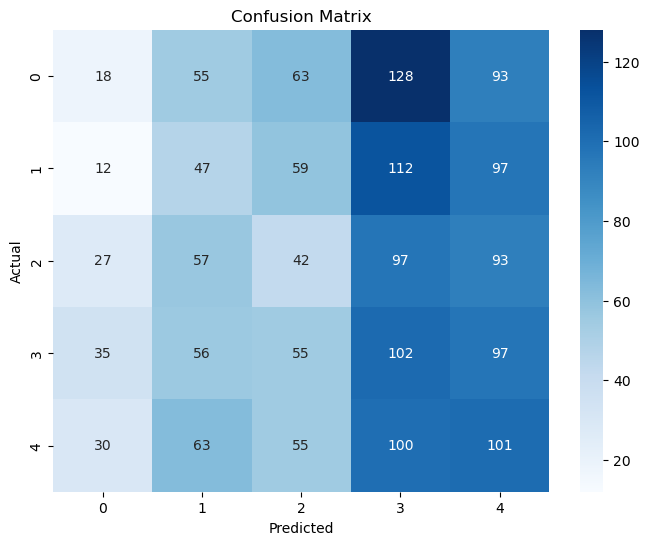

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8,6))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [14]:
# Target for priority prediction
y_priority = data['Ticket Priority']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

priority_model = MultinomialNB()

priority_model.fit(X_train_p, y_train_p)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [15]:
priority_pred = priority_model.predict(X_test_p)

print("Priority Prediction Accuracy:")

print(accuracy_score(y_test_p, priority_pred))

print("\nClassification Report\n")

print(classification_report(y_test_p, priority_pred))

Priority Prediction Accuracy:
0.2526564344746163

Classification Report

              precision    recall  f1-score   support

    Critical       0.25      0.29      0.27       411
        High       0.25      0.29      0.27       409
         Low       0.23      0.15      0.18       415
      Medium       0.27      0.28      0.27       459

    accuracy                           0.25      1694
   macro avg       0.25      0.25      0.25      1694
weighted avg       0.25      0.25      0.25      1694



In [16]:
# Example ticket
new_ticket = ["My laptop screen is broken and I need replacement"]

# Clean text
clean = clean_text(new_ticket[0])

# Convert to TF-IDF
vector = vectorizer.transform([clean])

# Predict category
category = model.predict(vector)

# Predict priority
priority = priority_model.predict(vector)

print("Predicted Ticket Category:", category[0])
print("Predicted Priority Level:", priority[0])

Predicted Ticket Category: Technical issue
Predicted Priority Level: Medium


In [17]:
vectorizer = TfidfVectorizer(max_features=3000)

X = vectorizer.fit_transform(data['clean_text'])

y = data['Ticket Type']

print(X.shape)

(8469, 3000)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (6775, 3000)
Testing data: (1694, 3000)


In [19]:
model = MultinomialNB()

model.fit(X_train, y_train)

print("Model training completed")

Model training completed


In [20]:
y_pred = model.predict(X_test)

print(y_pred[:10])

['Refund request' 'Product inquiry' 'Refund request'
 'Cancellation request' 'Technical issue' 'Refund request'
 'Refund request' 'Billing inquiry' 'Product inquiry' 'Product inquiry']


In [21]:
accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", accuracy)

Model Accuracy: 0.18240850059031877


In [22]:
print(classification_report(y_test, y_pred))

                      precision    recall  f1-score   support

     Billing inquiry       0.12      0.05      0.07       357
Cancellation request       0.18      0.17      0.18       327
     Product inquiry       0.15      0.15      0.15       316
      Refund request       0.19      0.27      0.22       345
     Technical issue       0.22      0.27      0.24       349

            accuracy                           0.18      1694
           macro avg       0.17      0.18      0.17      1694
        weighted avg       0.17      0.18      0.17      1694



In [23]:
y_priority = data['Ticket Priority']

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_priority, test_size=0.2, random_state=42
)

priority_model = MultinomialNB()

priority_model.fit(X_train_p, y_train_p)

priority_pred = priority_model.predict(X_test_p)

print("Priority Accuracy:", accuracy_score(y_test_p, priority_pred))

Priority Accuracy: 0.24970484061393153


In [24]:
new_ticket = ["My laptop screen is broken and not working"]

clean = clean_text(new_ticket[0])

vector = vectorizer.transform([clean])

category = model.predict(vector)

priority = priority_model.predict(vector)

print("Ticket:", new_ticket[0])
print("Predicted Category:", category[0])
print("Predicted Priority:", priority[0])

Ticket: My laptop screen is broken and not working
Predicted Category: Technical issue
Predicted Priority: Medium
